
  State-space dims  : (7, 5, 5, 5, 5, 3, 4)
  Total states      : 52,500
  Action space size : 9
  Q-table entries   : 472,500

  F-18 Q-LEARNING TRAINER  –  180° HEADING CHANGE MANEUVER
  Q-table shape : (7, 5, 5, 5, 5, 3, 4, 9)   (472,500 entries, 1.9 MB)
  Episodes      : 100,000
  α=0.15  γ=0.99  ε_start=1.0  ε_min=0.02
-----------------------------------------------------------------
  Ep 10,000 | AvgR= 23750.8 | Success= 63.8% | AvgHErr=  11.7° | ε=0.0498 | t=175s
  Ep 20,000 | AvgR= 20812.8 | Success= 46.8% | AvgHErr=  15.4° | ε=0.0200 | t=508s
  Ep 30,000 | AvgR= 22855.6 | Success= 43.8% | AvgHErr=  16.6° | ε=0.0200 | t=861s
  Ep 40,000 | AvgR= 26512.9 | Success= 39.2% | AvgHErr=  20.9° | ε=0.0200 | t=1226s
  Ep 50,000 | AvgR= 25564.2 | Success= 41.0% | AvgHErr=  18.7° | ε=0.0200 | t=1585s
  Ep 60,000 | AvgR= 25980.9 | Success= 31.2% | AvgHErr=  18.8° | ε=0.0200 | t=1957s
  Ep 70,000 | AvgR= 27022.3 | Success= 27.6% | AvgHErr=  25.3° | ε=0.0200 | t=2325s
  Ep 80,000 | AvgR= 26

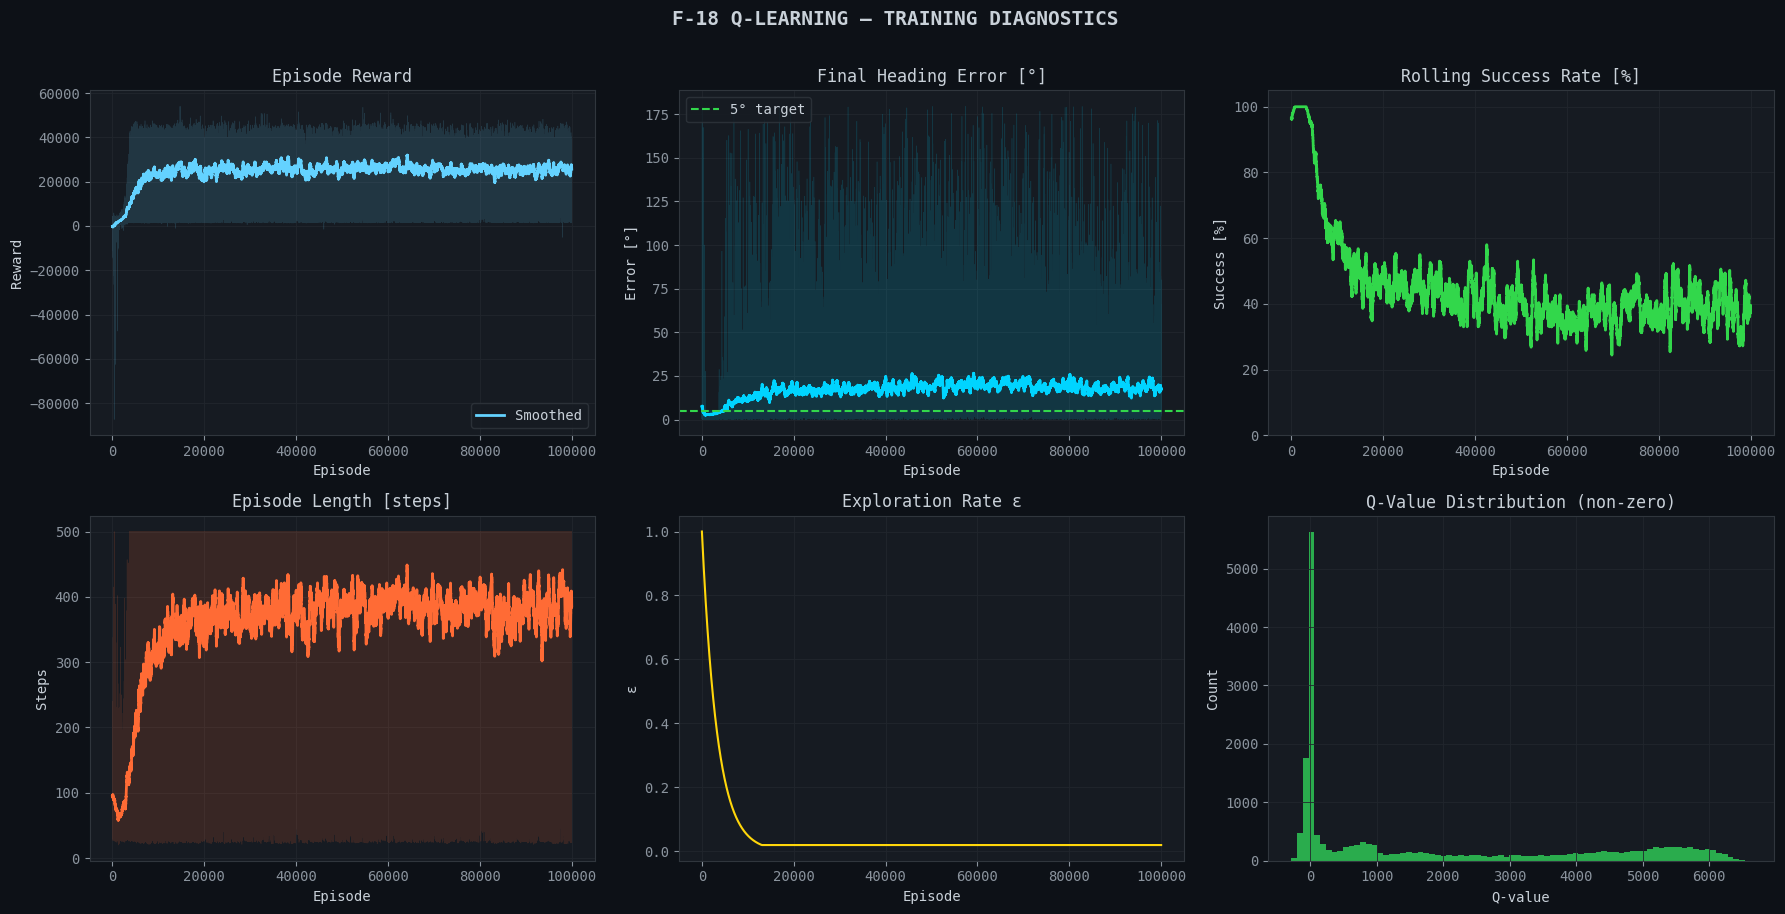

[Saved] training_curves.png
[Plotting] Maneuver trajectory …


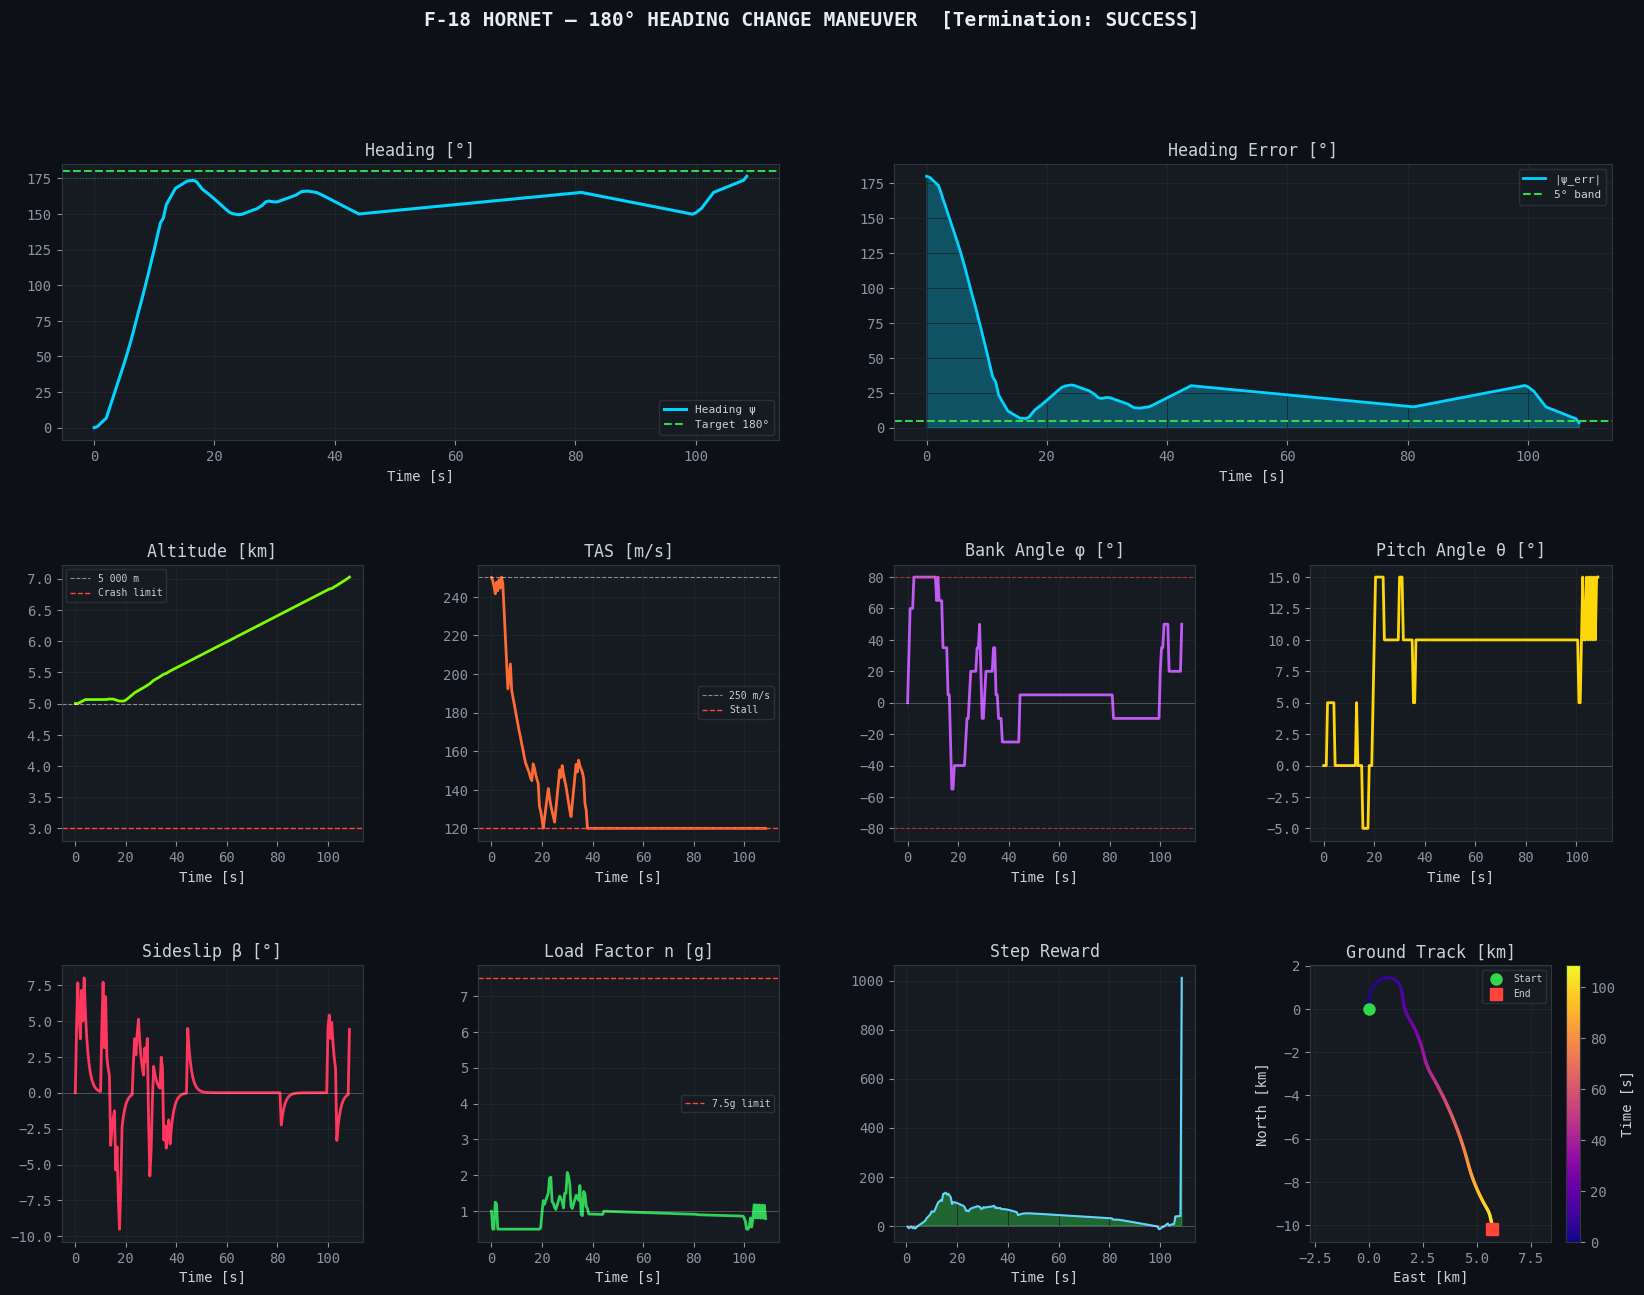

[Saved] maneuver_trajectory.png
[Plotting] Action distribution …


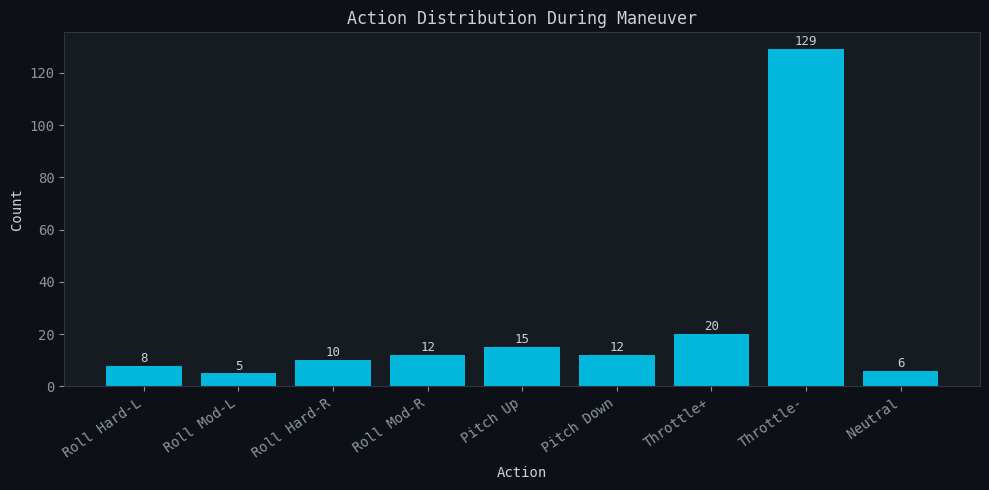

[Saved] action_distribution.png

[Optional] Discount-rate sensitivity (quick run) …

[Sensitivity] Running γ sweep …
  γ=0.90  → success=100.0%  mean_err=3.4°
  γ=0.95  → success=100.0%  mean_err=0.8°
  γ=0.97  → success=0.0%  mean_err=23.0°
  γ=0.99  → success=100.0%  mean_err=1.3°


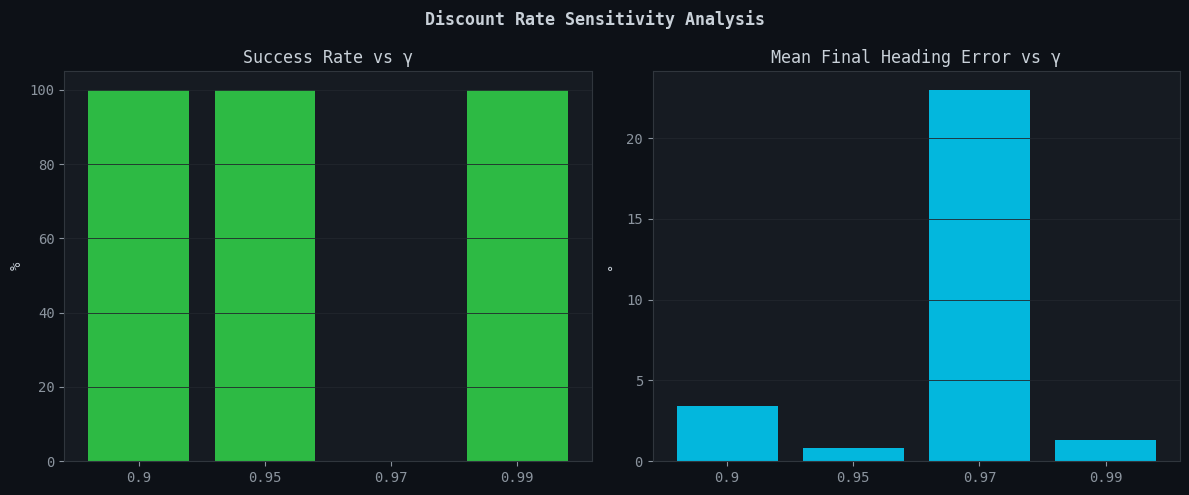

[Saved] gamma_sensitivity.png

✓  All done.


In [ ]:
"""
=============================================================================
  F-18 HORNET — TABULAR Q-LEARNING FOR 180° HEADING CHANGE MANEUVER
  Full 6-DOF Kinematic Model | Discrete State-Action Space | Complete Eval
=============================================================================

State space  : (heading_err_bin, alt_bin, vel_bin, bank_bin, pitch_bin,
                sideslip_bin, load_factor_bin)  → 7×5×5×5×5×3×4 = 52,500 states
Action space : 9 discrete actions
Algorithm    : Tabular Q-Learning with ε-greedy + decaying α schedule
"""

import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches
from collections import deque
import time
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 :  6-DOF KINEMATIC MODEL FOR F-18 HORNET
# ─────────────────────────────────────────────────────────────────────────────

class F18Dynamics:
    """
    Point-mass, 6-DOF kinematic model of the F/A-18C Hornet.

    State vector (continuous)
    ─────────────────────────
      heading   ψ   [deg]   – 0° = North, clockwise positive
      altitude  h   [m]
      velocity  V   [m/s]   – true airspeed
      bank      φ   [deg]   – roll angle (right-wing-down positive)
      pitch     θ   [deg]   – nose-up positive
      sideslip  β   [deg]   – positive nose-left
      load_fac  n   [g]     – aerodynamic normal load factor

    Actuator model (first-order lag)
    ─────────────────────────────────
      bank rate  ṗ  →  φ̇ = sat(ṗ, ±φ_rate_max)
      pitch rate q  →  θ̇ = sat(q,  ±θ_rate_max)
      thrust δ_T    →  V̇ = (T - D) / m
    """

    # ── Physical / aerodynamic constants ──────────────────────────────────
    G          = 9.81          # m/s²
    MASS       = 16_651        # kg  (F-18C combat weight)
    WING_AREA  = 37.16         # m²
    SPAN       = 11.43         # m
    RHO_SL     = 1.225         # kg/m³  (sea-level density)
    H_REF      = 8_500         # m      (scale height, rough exponential)

    # ── Aerodynamic coefficients (simplified) ────────────────────────────
    CD0   = 0.022              # parasite drag
    K     = 0.16               # induced drag factor  (1/π·AR·e)
    CL_α  = 5.0                # lift-curve slope  [/rad]
    CL0   = 0.1                # zero-α lift
    CY_β  = -0.9               # side-force vs sideslip [/rad]

    # ── Actuator limits (F-18 envelope) ──────────────────────────────────
    BANK_MAX      =  80.0      # deg
    BANK_RATE_MAX =  60.0      # deg/s
    PITCH_MAX     =  25.0      # deg
    PITCH_MIN     = -20.0      # deg
    PITCH_RATE_MAX=  15.0      # deg/s
    V_MIN         = 120.0      # m/s  (≈ 233 kt, well above stall)
    V_MAX         = 510.0      # m/s  (≈ M1.6 at altitude)
    THROTTLE_RATE =  30.0      # m/s per step (velocity change per action)
    BETA_MAX      =  15.0      # deg  (sideslip limit)

    def __init__(self, dt: float = 0.5):
        self.dt = dt
        self.reset()

    # ── State initialisation ─────────────────────────────────────────────
    def reset(self):
        self.heading  =   0.0        # will turn to 180°
        self.altitude = 5_000.0      # m
        self.velocity =   250.0      # m/s  (≈ 486 kt)
        self.bank     =   0.0        # wings level
        self.pitch    =   0.0
        self.sideslip =   0.0
        self.load_fac =   1.0
        self.steps    =   0
        return self._state_vector()

    def _state_vector(self):
        return dict(
            heading  = self.heading,
            altitude = self.altitude,
            velocity = self.velocity,
            bank     = self.bank,
            pitch    = self.pitch,
            sideslip = self.sideslip,
            load_fac = self.load_fac,
        )

    # ── Atmosphere model (ISA exponential) ───────────────────────────────
    def _air_density(self):
        return self.RHO_SL * np.exp(-self.altitude / self.H_REF)

    # ── Aerodynamic forces ───────────────────────────────────────────────
    def _aero(self):
        rho = self._air_density()
        q_bar = 0.5 * rho * self.velocity**2          # dynamic pressure  [Pa]

        α_rad = np.radians(self.pitch)
        β_rad = np.radians(self.sideslip)

        CL = self.CL0 + self.CL_α * α_rad
        CL = np.clip(CL, 0.0, 2.0)                   # stall limit

        CD = self.CD0 + self.K * CL**2
        CY = self.CY_β * β_rad

        lift  = q_bar * self.WING_AREA * CL
        drag  = q_bar * self.WING_AREA * CD
        side  = q_bar * self.WING_AREA * CY

        return lift, drag, side

    # ── Equations of motion ──────────────────────────────────────────────
    def step_dynamics(self, d_bank: float, d_pitch: float, d_vel: float):
        """
        Integrate one time-step given incremental control inputs.

        Parameters
        ----------
        d_bank  : desired bank-angle change  [deg]  (saturated internally)
        d_pitch : desired pitch change        [deg]
        d_vel   : desired velocity change     [m/s]  (throttle / speed-brake)
        """
        self.steps += 1

        # ── 1. Actuator dynamics (rate limiting) ──────────────────────
        d_bank  = np.clip(d_bank,  -self.BANK_RATE_MAX  * self.dt,
                                    self.BANK_RATE_MAX  * self.dt)
        d_pitch = np.clip(d_pitch, -self.PITCH_RATE_MAX * self.dt,
                                    self.PITCH_RATE_MAX * self.dt)

        self.bank     = np.clip(self.bank  + d_bank,  -self.BANK_MAX,  self.BANK_MAX)
        self.pitch    = np.clip(self.pitch + d_pitch,  self.PITCH_MIN, self.PITCH_MAX)

        # ── 2. Aerodynamic forces ─────────────────────────────────────
        lift, drag, side = self._aero()

        # ── 3. Load factor  n = L·cos(φ) / (m·g) ────────────────────
        phi_rad = np.radians(self.bank)
        self.load_fac = (lift * np.cos(phi_rad)) / (self.MASS * self.G)
        self.load_fac = np.clip(self.load_fac, 0.5, 9.0)

        # ── 4. Turn rate (coordinated turn approximation) ─────────────
        # ψ̇ = g·tan(φ) / V   (wings-level centripetal equation)
        turn_rate = (self.G * np.tan(phi_rad)) / max(self.velocity, 50.0)
        self.heading += np.degrees(turn_rate) * self.dt
        self.heading  = self.heading % 360.0

        # ── 5. Altitude rate  ḣ = V·sin(θ) ──────────────────────────
        self.altitude += self.velocity * np.sin(np.radians(self.pitch)) * self.dt

        # ── 6. Velocity (thrust minus drag plus throttle input) ───────
        # Net acceleration = (d_vel commanded) - induced drag bleed
        induced_drag_decel = (abs(self.bank) * 0.08 +
                              abs(self.pitch) * 0.30 +
                              self.load_fac  * 1.50)
        self.velocity += d_vel * self.dt - induced_drag_decel * self.dt
        self.velocity  = np.clip(self.velocity, self.V_MIN, self.V_MAX)

        # ── 7. Sideslip (yaw due to roll, decays naturally) ───────────
        # Simple kinematic: β grows with abrupt roll, damps at β_rate
        β_drive = 0.15 * d_bank / self.dt          # coupling from roll
        β_damp  = -0.6 * self.sideslip             # restoring moment
        self.sideslip += (β_drive + β_damp) * self.dt
        self.sideslip  = np.clip(self.sideslip, -self.BETA_MAX, self.BETA_MAX)

        return self._state_vector()


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 :  DISCRETE OBSERVATION SPACE
# ─────────────────────────────────────────────────────────────────────────────

class StateDiscretizer:
    """
    Maps the continuous 6-DOF state to a tuple index into the Q-table.

    Bins
    ────
    heading_err : 7 bins  – [0,15) [15,30) [30,60) [60,90) [90,120) [120,150) [150,180+]
    altitude    : 5 bins  – critical / low / nominal / high / extreme-high
    velocity    : 5 bins  – stall / slow / cruise / fast / supersonic
    bank        : 5 bins  – hard-left / left / level / right / hard-right
    pitch       : 5 bins  – steep-dn / dn / level / up / steep-up
    sideslip    : 3 bins  – left / center / right
    load_factor : 4 bins  – low / normal / high / structural-limit

    Total states : 7×5×5×5×5×3×4 = 52,500
    """

    DIMS = (7, 5, 5, 5, 5, 3, 4)
    TARGET_HEADING = 180.0

    @staticmethod
    def heading_error(heading: float) -> float:
        """Shortest angular distance to 180° target."""
        err = abs(StateDiscretizer.TARGET_HEADING - heading)
        return min(err, 360.0 - err)

    @classmethod
    def discretize(cls, sv: dict) -> tuple:
        h_err = cls.heading_error(sv['heading'])

        # ── heading error → 7 bins ────────────────────────────────────
        thresholds = [15, 30, 60, 90, 120, 150]
        h_bin = sum(h_err >= t for t in thresholds)          # 0..6

        # ── altitude → 5 bins ────────────────────────────────────────
        alt = sv['altitude']
        if   alt < 3_000:  alt_bin = 0   # critical (too low)
        elif alt < 4_500:  alt_bin = 1   # low
        elif alt < 5_500:  alt_bin = 2   # nominal band
        elif alt < 7_000:  alt_bin = 3   # high
        else:              alt_bin = 4   # extreme high

        # ── velocity → 5 bins ────────────────────────────────────────
        vel = sv['velocity']
        if   vel < 150:   vel_bin = 0   # stall danger
        elif vel < 200:   vel_bin = 1   # slow
        elif vel < 310:   vel_bin = 2   # cruise band
        elif vel < 400:   vel_bin = 3   # fast
        else:             vel_bin = 4   # supersonic

        # ── bank → 5 bins ────────────────────────────────────────────
        bk = sv['bank']
        if   bk < -45:   bank_bin = 0   # hard left
        elif bk < -15:   bank_bin = 1   # left
        elif bk <=  15:  bank_bin = 2   # wings level
        elif bk <=  45:  bank_bin = 3   # right
        else:            bank_bin = 4   # hard right

        # ── pitch → 5 bins ───────────────────────────────────────────
        pt = sv['pitch']
        if   pt < -10:   pitch_bin = 0
        elif pt <  -3:   pitch_bin = 1
        elif pt <=   3:  pitch_bin = 2
        elif pt <=  10:  pitch_bin = 3
        else:            pitch_bin = 4

        # ── sideslip → 3 bins ────────────────────────────────────────
        bs = sv['sideslip']
        if   bs < -5:    slip_bin = 0
        elif bs <=  5:   slip_bin = 1
        else:            slip_bin = 2

        # ── load factor → 4 bins ─────────────────────────────────────
        nz = sv['load_fac']
        if   nz < 1.5:   nz_bin = 0   # unloaded / low-g
        elif nz < 3.0:   nz_bin = 1   # normal maneuvering
        elif nz < 6.0:   nz_bin = 2   # high-g
        else:            nz_bin = 3   # near structural limit

        return (h_bin, alt_bin, vel_bin, bank_bin, pitch_bin, slip_bin, nz_bin)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 :  GYM-STYLE ENVIRONMENT
# ─────────────────────────────────────────────────────────────────────────────

class F18ManeuverEnv:
    """
    RL environment wrapping F18Dynamics for the 180° heading change task.

    Action space (9 discrete actions)
    ──────────────────────────────────
    0 : Roll hard-left   (Δφ = -30°)
    1 : Roll moderate-left (Δφ = -15°)
    2 : Roll hard-right  (Δφ = +30°)
    3 : Roll moderate-right (Δφ = +15°)
    4 : Pitch up         (Δθ = +5°)
    5 : Pitch down       (Δθ = -5°)
    6 : Throttle up      (ΔV = +20 m/s)
    7 : Throttle down    (ΔV = -20 m/s)
    8 : Neutral          (hold current attitudes)

    Episode termination
    ───────────────────
    • Heading error ≤ 5° AND altitude in safe band   → SUCCESS
    • Altitude < 3 000 m                              → CRASH
    • Velocity < 120 m/s                              → STALL
    • Steps > max_steps                               → TIMEOUT
    """

    N_ACTIONS  = 9
    MAX_STEPS  = 500           # ~100 s at dt=0.5 s per step
    SUCCESS_ERR = 5.0          # degrees

    # Action → (d_bank, d_pitch, d_vel)
    ACTION_MAP = {
        0: (-30.0,  0.0,   0.0),
        1: (-15.0,  0.0,   0.0),
        2: (+30.0,  0.0,   0.0),
        3: (+15.0,  0.0,   0.0),
        4: (  0.0, +5.0,   0.0),
        5: (  0.0, -5.0,   0.0),
        6: (  0.0,  0.0, +20.0),
        7: (  0.0,  0.0, -20.0),
        8: (  0.0,  0.0,   0.0),
    }

    def __init__(self, dt: float = 0.5):
        self.dyn  = F18Dynamics(dt=dt)
        self.disc = StateDiscretizer()

    def reset(self):
        sv = self.dyn.reset()
        return self.disc.discretize(sv), sv

    def step(self, action: int):
        d_bank, d_pitch, d_vel = self.ACTION_MAP[action]
        sv   = self.dyn.step_dynamics(d_bank, d_pitch, d_vel)
        ds   = self.disc.discretize(sv)

        reward, done, info = self._reward_and_terminal(sv, ds)
        return ds, sv, reward, done, info

    # ── Reward function ──────────────────────────────────────────────────
    def _reward_and_terminal(self, sv: dict, ds: tuple):
        h_bin, alt_bin, vel_bin, bank_bin, pitch_bin, slip_bin, nz_bin = ds
        h_err = StateDiscretizer.heading_error(sv['heading'])

        done = False
        info = {'cause': 'running'}

        # ── 1. Progress reward (inverse heading error) ────────────────
        #       Max +100 at h_err=0, +0 at h_err=180
        r_heading = 100.0 * (1.0 - h_err / 180.0)**2

        # ── 2. Altitude safety ────────────────────────────────────────
        alt_deviation = abs(sv['altitude'] - 5_000.0)
        r_altitude = -0.05 * alt_deviation          # penalise drift from 5 000 m

        # ── 3. Velocity maintenance ───────────────────────────────────
        vel_deviation = abs(sv['velocity'] - 250.0)
        r_velocity = -0.02 * vel_deviation

        # ── 4. Sideslip penalty (coordinated turn) ────────────────────
        r_sideslip = -2.0 * abs(sv['sideslip'])

        # ── 5. Load factor penalty  ───────────────────────────────────
        r_nz = -3.0 * max(0.0, sv['load_fac'] - 6.5)   # only penalise >6.5g

        # ── 6. Bank efficiency bonus (positive bank → clockwise turn) ─
        #       Encourage right-bank for a left-to-right 180° turn
        r_bank_eff = 0.0
        if sv['bank'] > 20.0 and h_err > 10.0:
            r_bank_eff = 5.0    # bonus for sustained useful bank

        # ── 7. Milestone bonuses ──────────────────────────────────────
        r_milestone = 0.0
        if   h_err < 10:  r_milestone = 50.0
        elif h_err < 30:  r_milestone = 20.0
        elif h_err < 60:  r_milestone = 10.0
        elif h_err < 90:  r_milestone =  5.0

        # ── 8. Terminal conditions ────────────────────────────────────
        if sv['altitude'] < 3_000.0:
            done = True
            info = {'cause': 'crash'}
            return -500.0, done, info          # terminal crash penalty

        if sv['velocity'] < F18Dynamics.V_MIN:
            done = True
            info = {'cause': 'stall'}
            return -300.0, done, info

        if h_err <= self.SUCCESS_ERR and alt_bin >= 1:
            # Levelling bonus: reward wings-level recovery
            wings_level_bonus = 30.0 * (1.0 - abs(sv['bank']) / 80.0)
            done = True
            info = {'cause': 'success'}
            return (1000.0 + wings_level_bonus), done, info

        if self.dyn.steps >= self.MAX_STEPS:
            done = True
            info = {'cause': 'timeout'}
            # Partial credit for getting close
            return (r_heading - 50.0), done, info

        total_reward = (r_heading + r_altitude + r_velocity +
                        r_sideslip + r_nz + r_bank_eff + r_milestone)
        return total_reward, done, info


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 :  TABULAR Q-LEARNING TRAINER
# ─────────────────────────────────────────────────────────────────────────────

class QLearningTrainer:
    """
    Standard tabular Q-Learning with:
      • ε-greedy exploration with exponential decay
      • Per-step learning-rate decay schedule
      • Episode statistics tracking
    """

    def __init__(self,
                 env: F18ManeuverEnv,
                 alpha:       float = 0.15,
                 gamma:       float = 0.99,
                 epsilon_start: float = 1.0,
                 epsilon_min:   float = 0.02,
                 epsilon_decay: float = 0.9997):

        self.env           = env
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon_start
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay

        dims = StateDiscretizer.DIMS + (env.N_ACTIONS,)
        self.Q = np.zeros(dims, dtype=np.float32)

        # ── Statistics buffers ────────────────────────────────────────
        self.ep_rewards      = []
        self.ep_steps        = []
        self.ep_success      = []
        self.ep_final_herr   = []
        self.ep_epsilons     = []
        self.running_reward  = deque(maxlen=200)

    # ── Policy ───────────────────────────────────────────────────────────
    def select_action(self, state: tuple) -> int:
        if random.random() < self.epsilon:
            return random.randint(0, self.env.N_ACTIONS - 1)
        return int(np.argmax(self.Q[state]))

    # ── Single episode ────────────────────────────────────────────────────
    def run_episode(self) -> dict:
        state, sv = self.env.reset()
        done      = False
        ep_reward = 0.0
        ep_steps  = 0

        while not done:
            action = self.select_action(state)
            next_state, sv_next, reward, done, info = self.env.step(action)

            # Bellman update
            best_next = float(np.max(self.Q[next_state]))
            td_target = reward + self.gamma * best_next * (not done)
            td_error  = td_target - float(self.Q[state][action])
            self.Q[state][action] += self.alpha * td_error

            state      = next_state
            ep_reward += reward
            ep_steps  += 1

        h_err_final = StateDiscretizer.heading_error(sv_next['heading'])
        return {
            'reward'   : ep_reward,
            'steps'    : ep_steps,
            'success'  : info['cause'] == 'success',
            'cause'    : info['cause'],
            'h_err'    : h_err_final,
        }

    # ── Training loop ─────────────────────────────────────────────────────
    def train(self, n_episodes: int = 100_000, print_every: int = 10_000):
        print("=" * 65)
        print("  F-18 Q-LEARNING TRAINER  –  180° HEADING CHANGE MANEUVER")
        print("=" * 65)
        print(f"  Q-table shape : {self.Q.shape}   "
              f"({self.Q.size:,} entries, {self.Q.nbytes/1e6:.1f} MB)")
        print(f"  Episodes      : {n_episodes:,}")
        print(f"  α={self.alpha}  γ={self.gamma}  "
              f"ε_start={self.epsilon}  ε_min={self.epsilon_min}")
        print("-" * 65)

        t0 = time.time()
        success_window = deque(maxlen=500)

        for ep in range(1, n_episodes + 1):
            result = self.run_episode()

            self.ep_rewards.append(result['reward'])
            self.ep_steps.append(result['steps'])
            self.ep_success.append(int(result['success']))
            self.ep_final_herr.append(result['h_err'])
            self.ep_epsilons.append(self.epsilon)
            self.running_reward.append(result['reward'])
            success_window.append(int(result['success']))

            # Decay exploration
            self.epsilon = max(self.epsilon_min,
                               self.epsilon * self.epsilon_decay)

            if ep % print_every == 0:
                avg_r   = np.mean(list(self.running_reward))
                suc_rt  = 100 * np.mean(list(success_window))
                avg_err = np.mean(self.ep_final_herr[-200:])
                elapsed = time.time() - t0
                print(f"  Ep {ep:>6,} | "
                      f"AvgR={avg_r:>8.1f} | "
                      f"Success={suc_rt:>5.1f}% | "
                      f"AvgHErr={avg_err:>6.1f}° | "
                      f"ε={self.epsilon:.4f} | "
                      f"t={elapsed:.0f}s")

        print("-" * 65)
        final_suc = 100 * np.mean(self.ep_success[-5000:])
        print(f"  Training complete in {time.time()-t0:.1f}s")
        print(f"  Final 5000-episode success rate : {final_suc:.1f}%")
        print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 :  GREEDY POLICY EVALUATION & TRAJECTORY COLLECTION
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_greedy(env: F18ManeuverEnv, Q: np.ndarray,
                    n_eval: int = 100) -> dict:
    """Run greedy rollouts and collect statistics."""
    successes, h_errors, step_counts, rewards = [], [], [], []

    for _ in range(n_eval):
        state, sv = env.reset()
        done = False
        ep_r = 0.0
        while not done:
            action = int(np.argmax(Q[state]))
            state, sv, rew, done, info = env.step(action)
            ep_r += rew

        successes.append(info['cause'] == 'success')
        h_errors.append(StateDiscretizer.heading_error(sv['heading']))
        step_counts.append(env.dyn.steps)
        rewards.append(ep_r)

    return dict(
        success_rate = np.mean(successes),
        mean_h_err   = np.mean(h_errors),
        std_h_err    = np.std(h_errors),
        mean_steps   = np.mean(step_counts),
        mean_reward  = np.mean(rewards),
    )


def record_trajectory(env: F18ManeuverEnv, Q: np.ndarray) -> dict:
    """Execute one greedy episode and log continuous state at every step."""
    state, sv = env.reset()
    done  = False

    traj = {k: [sv[k]] for k in sv}
    traj['time']   = [0.0]
    traj['action'] = []
    traj['reward'] = []
    traj['h_err']  = [StateDiscretizer.heading_error(sv['heading'])]

    t = 0.0
    while not done:
        action = int(np.argmax(Q[state]))
        state, sv, rew, done, info = env.step(action)
        t += env.dyn.dt

        for k in list(sv.keys()):
            traj[k].append(sv[k])
        traj['time'].append(t)
        traj['action'].append(action)
        traj['reward'].append(rew)
        traj['h_err'].append(StateDiscretizer.heading_error(sv['heading']))

        traj['termination'] = info['cause']
    return traj


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 :  VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────

ACTION_LABELS = [
    'Roll Hard-L', 'Roll Mod-L', 'Roll Hard-R', 'Roll Mod-R',
    'Pitch Up',    'Pitch Down', 'Throttle+',   'Throttle-',
    'Neutral'
]

COLORS = {
    'heading'  : '#00d4ff',
    'altitude' : '#7cfc00',
    'velocity' : '#ff6b35',
    'bank'     : '#bf5af2',
    'pitch'    : '#ffd60a',
    'sideslip' : '#ff375f',
    'load_fac' : '#30d158',
    'reward'   : '#64d2ff',
    'success'  : '#32d74b',
    'fail'     : '#ff453a',
    'eps'      : '#ffd60a',
}

plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#161b22',
    'axes.edgecolor'   : '#30363d',
    'axes.labelcolor'  : '#c9d1d9',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'text.color'       : '#c9d1d9',
    'grid.color'       : '#21262d',
    'grid.linewidth'   : 0.6,
    'legend.facecolor' : '#161b22',
    'legend.edgecolor' : '#30363d',
    'font.family'      : 'monospace',
})


def smooth(x, w=200):
    if len(x) < w:
        w = max(1, len(x) // 4)
    return np.convolve(x, np.ones(w)/w, mode='valid')


def plot_training_curves(trainer: QLearningTrainer):
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    fig.suptitle("F-18 Q-LEARNING — TRAINING DIAGNOSTICS",
                 fontsize=14, fontweight='bold', color='#c9d1d9', y=1.01)

    eps_arr = np.array(trainer.ep_rewards)
    n_ep = len(eps_arr)
    x    = np.arange(n_ep)

    # ── 1. Episode reward ─────────────────────────────────────────────
    ax = axes[0, 0]
    ax.plot(x, eps_arr, alpha=0.15, color=COLORS['reward'], lw=0.4)
    sm = smooth(eps_arr, 300)
    ax.plot(np.linspace(0, n_ep, len(sm)), sm,
            color=COLORS['reward'], lw=2.0, label='Smoothed')
    ax.set_title("Episode Reward", color='#c9d1d9')
    ax.set_xlabel("Episode"); ax.set_ylabel("Reward")
    ax.legend(); ax.grid(True)

    # ── 2. Heading error at episode end ──────────────────────────────
    ax = axes[0, 1]
    herr = np.array(trainer.ep_final_herr)
    ax.plot(x, herr, alpha=0.15, color=COLORS['heading'], lw=0.4)
    sm = smooth(herr, 300)
    ax.plot(np.linspace(0, n_ep, len(sm)), sm,
            color=COLORS['heading'], lw=2.0)
    ax.axhline(5, color=COLORS['success'], lw=1.5, ls='--', label='5° target')
    ax.set_title("Final Heading Error [°]", color='#c9d1d9')
    ax.set_xlabel("Episode"); ax.set_ylabel("Error [°]")
    ax.legend(); ax.grid(True)

    # ── 3. Rolling success rate ───────────────────────────────────────
    ax = axes[0, 2]
    suc = np.array(trainer.ep_success, dtype=float)
    sm = smooth(suc, 500) * 100
    ax.plot(np.linspace(0, n_ep, len(sm)), sm,
            color=COLORS['success'], lw=2.0)
    ax.set_ylim(0, 105)
    ax.set_title("Rolling Success Rate [%]", color='#c9d1d9')
    ax.set_xlabel("Episode"); ax.set_ylabel("Success [%]")
    ax.grid(True)

    # ── 4. Episode length ─────────────────────────────────────────────
    ax = axes[1, 0]
    steps = np.array(trainer.ep_steps, dtype=float)
    ax.plot(x, steps, alpha=0.15, color=COLORS['velocity'], lw=0.4)
    sm = smooth(steps, 300)
    ax.plot(np.linspace(0, n_ep, len(sm)), sm,
            color=COLORS['velocity'], lw=2.0)
    ax.set_title("Episode Length [steps]", color='#c9d1d9')
    ax.set_xlabel("Episode"); ax.set_ylabel("Steps")
    ax.grid(True)

    # ── 5. Epsilon decay ─────────────────────────────────────────────
    ax = axes[1, 1]
    ax.plot(x, trainer.ep_epsilons, color=COLORS['eps'], lw=1.5)
    ax.set_title("Exploration Rate ε", color='#c9d1d9')
    ax.set_xlabel("Episode"); ax.set_ylabel("ε")
    ax.grid(True)

    # ── 6. Q-value distribution (sampled) ────────────────────────────
    ax = axes[1, 2]
    q_flat = trainer.Q.flatten()
    nonzero = q_flat[q_flat != 0]
    if len(nonzero) > 0:
        ax.hist(nonzero, bins=80, color=COLORS['load_fac'],
                alpha=0.8, edgecolor='none')
    ax.set_title("Q-Value Distribution (non-zero)", color='#c9d1d9')
    ax.set_xlabel("Q-value"); ax.set_ylabel("Count")
    ax.grid(True)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("[Saved] training_curves.png")


def plot_maneuver_trajectory(traj: dict):
    fig = plt.figure(figsize=(20, 14))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(
        f"F-18 HORNET — 180° HEADING CHANGE MANEUVER  "
        f"[Termination: {traj['termination'].upper()}]",
        fontsize=14, fontweight='bold', color='#e6edf3', y=0.99
    )

    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)

    t = np.array(traj['time'])

    # ── (a) Heading timeline ──────────────────────────────────────────
    ax = fig.add_subplot(gs[0, :2])
    ax.plot(t, traj['heading'], color=COLORS['heading'], lw=2.2, label='Heading ψ')
    ax.axhline(180, color=COLORS['success'], lw=1.5, ls='--', label='Target 180°')
    ax.axhline(175, color=COLORS['success'], lw=0.8, ls=':', alpha=0.5)
    ax.axhline(185, color=COLORS['success'], lw=0.8, ls=':', alpha=0.5)
    ax.set_title("Heading [°]", color='#c9d1d9'); ax.grid(True)
    ax.set_xlabel("Time [s]"); ax.legend(fontsize=8)

    # ── (b) Heading error ─────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 2:])
    ax.fill_between(t, traj['h_err'], alpha=0.3, color=COLORS['heading'])
    ax.plot(t, traj['h_err'], color=COLORS['heading'], lw=2.0, label='|ψ_err|')
    ax.axhline(5, color=COLORS['success'], lw=1.5, ls='--', label='5° band')
    ax.set_title("Heading Error [°]", color='#c9d1d9'); ax.grid(True)
    ax.set_xlabel("Time [s]"); ax.legend(fontsize=8)

    # ── (c) Altitude ──────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(t, np.array(traj['altitude'])/1000, color=COLORS['altitude'], lw=2.0)
    ax.axhline(5.0, color='white', lw=0.8, ls='--', alpha=0.5, label='5 000 m')
    ax.axhline(3.0, color=COLORS['fail'], lw=1.0, ls='--', label='Crash limit')
    ax.set_title("Altitude [km]", color='#c9d1d9'); ax.grid(True)
    ax.set_xlabel("Time [s]"); ax.legend(fontsize=7)

    # ── (d) Velocity ──────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    ax.plot(t, traj['velocity'], color=COLORS['velocity'], lw=2.0)
    ax.axhline(250, color='white', lw=0.8, ls='--', alpha=0.5, label='250 m/s')
    ax.axhline(120, color=COLORS['fail'],  lw=1.0, ls='--', label='Stall')
    ax.set_title("TAS [m/s]", color='#c9d1d9'); ax.grid(True)
    ax.set_xlabel("Time [s]"); ax.legend(fontsize=7)

    # ── (e) Bank angle ────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 2])
    ax.plot(t, traj['bank'], color=COLORS['bank'], lw=2.0)
    ax.axhline( 80, color=COLORS['fail'], lw=0.8, ls='--', alpha=0.6)
    ax.axhline(-80, color=COLORS['fail'], lw=0.8, ls='--', alpha=0.6)
    ax.axhline(0, color='white', lw=0.5, ls='-', alpha=0.3)
    ax.set_title("Bank Angle φ [°]", color='#c9d1d9'); ax.grid(True)
    ax.set_xlabel("Time [s]")

    # ── (f) Pitch angle ───────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 3])
    ax.plot(t, traj['pitch'], color=COLORS['pitch'], lw=2.0)
    ax.axhline(0, color='white', lw=0.5, ls='-', alpha=0.3)
    ax.set_title("Pitch Angle θ [°]", color='#c9d1d9'); ax.grid(True)
    ax.set_xlabel("Time [s]")

    # ── (g) Sideslip ──────────────────────────────────────────────────
    ax = fig.add_subplot(gs[2, 0])
    ax.plot(t, traj['sideslip'], color=COLORS['sideslip'], lw=2.0)
    ax.axhline(0, color='white', lw=0.5, ls='-', alpha=0.3)
    ax.set_title("Sideslip β [°]", color='#c9d1d9'); ax.grid(True)
    ax.set_xlabel("Time [s]")

    # ── (h) Load factor ───────────────────────────────────────────────
    ax = fig.add_subplot(gs[2, 1])
    ax.plot(t, traj['load_fac'], color=COLORS['load_fac'], lw=2.0)
    ax.axhline(7.5, color=COLORS['fail'], lw=1.0, ls='--', label='7.5g limit')
    ax.axhline(1.0, color='white', lw=0.5, ls='-', alpha=0.3)
    ax.set_title("Load Factor n [g]", color='#c9d1d9'); ax.grid(True)
    ax.set_xlabel("Time [s]"); ax.legend(fontsize=7)

    # ── (i) Step reward ───────────────────────────────────────────────
    ax = fig.add_subplot(gs[2, 2])
    if traj['reward']:
        rews = np.array(traj['reward'])
        ax.fill_between(t[1:], rews, where=rews >= 0,
                        alpha=0.4, color=COLORS['success'])
        ax.fill_between(t[1:], rews, where=rews < 0,
                        alpha=0.4, color=COLORS['fail'])
        ax.plot(t[1:], rews, color=COLORS['reward'], lw=1.5)
    ax.axhline(0, color='white', lw=0.5, ls='-', alpha=0.3)
    ax.set_title("Step Reward", color='#c9d1d9'); ax.grid(True)
    ax.set_xlabel("Time [s]")

    # ── (j) Horizontal track (top-down) ──────────────────────────────
    ax = fig.add_subplot(gs[2, 3])
    # Compute crude ground track from heading and speed
    headings = np.array(traj['heading'])
    vels     = np.array(traj['velocity'])
    x_pos    = np.cumsum(vels[:-1] * np.sin(np.radians(headings[:-1])) * env.dyn.dt)
    y_pos    = np.cumsum(vels[:-1] * np.cos(np.radians(headings[:-1])) * env.dyn.dt)
    x_pos    = np.concatenate([[0], x_pos]) / 1000   # km
    y_pos    = np.concatenate([[0], y_pos]) / 1000

    sc = ax.scatter(x_pos, y_pos, c=t, cmap='plasma',
                    s=6, linewidths=0, zorder=3)
    ax.plot(x_pos, y_pos, color='white', lw=0.5, alpha=0.3, zorder=2)
    ax.plot(x_pos[0], y_pos[0], 'o', color=COLORS['success'],
            ms=8, label='Start', zorder=4)
    ax.plot(x_pos[-1], y_pos[-1], 's', color=COLORS['fail'],
            ms=8, label='End', zorder=4)
    plt.colorbar(sc, ax=ax, label='Time [s]')
    ax.set_title("Ground Track [km]", color='#c9d1d9')
    ax.set_xlabel("East [km]"); ax.set_ylabel("North [km]")
    ax.legend(fontsize=7); ax.grid(True); ax.set_aspect('equal', adjustable='datalim')

    plt.savefig("maneuver_trajectory.png", dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("[Saved] maneuver_trajectory.png")


def plot_action_distribution(traj: dict):
    if not traj['action']:
        return
    actions = np.array(traj['action'])
    counts  = [np.sum(actions == a) for a in range(9)]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(ACTION_LABELS, counts,
                  color=COLORS['heading'], edgecolor='none', alpha=0.85)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(cnt), ha='center', va='bottom', fontsize=9)
    ax.set_title("Action Distribution During Maneuver", color='#c9d1d9', fontsize=12)
    ax.set_xlabel("Action"); ax.set_ylabel("Count")
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig("action_distribution.png", dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("[Saved] action_distribution.png")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 :  STEP-BY-STEP CONSOLE REPORT
# ─────────────────────────────────────────────────────────────────────────────

def print_maneuver_table(traj: dict):
    print("\n" + "=" * 95)
    print("  F-18 GREEDY MANEUVER ROLL-OUT   —   180° Heading Change")
    print("=" * 95)
    hdr = (f"{'t[s]':>5} | {'ψ[°]':>7} | {'Err[°]':>7} | "
           f"{'Alt[m]':>7} | {'V[m/s]':>7} | {'φ[°]':>6} | "
           f"{'θ[°]':>5} | {'β[°]':>5} | {'n[g]':>5} | {'Action':<14} | {'Reward':>8}")
    print(hdr)
    print("-" * 95)

    for i, t_val in enumerate(traj['time']):
        act_str = ACTION_LABELS[traj['action'][i-1]] if i > 0 and traj['action'] else '-'
        rew_str = f"{traj['reward'][i-1]:>8.1f}" if i > 0 and traj['reward'] else '       -'
        print(
            f"{t_val:>5.1f} | "
            f"{traj['heading'][i]:>7.1f} | "
            f"{traj['h_err'][i]:>7.1f} | "
            f"{traj['altitude'][i]:>7.0f} | "
            f"{traj['velocity'][i]:>7.1f} | "
            f"{traj['bank'][i]:>6.1f} | "
            f"{traj['pitch'][i]:>5.1f} | "
            f"{traj['sideslip'][i]:>5.1f} | "
            f"{traj['load_fac'][i]:>5.2f} | "
            f"{act_str:<14} | "
            f"{rew_str}"
        )

    print("=" * 95)
    print(f"  Termination : {traj['termination'].upper()}")
    print(f"  Total steps : {len(traj['time'])-1}")
    print(f"  Total time  : {traj['time'][-1]:.1f} s")
    print(f"  Final ψ     : {traj['heading'][-1]:.1f}°  "
          f"(error = {traj['h_err'][-1]:.1f}°)")
    if traj['reward']:
        print(f"  Cumul reward: {sum(traj['reward']):.1f}")
    print("=" * 95)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 :  SENSITIVITY ANALYSIS  (discount-rate sweep)
# ─────────────────────────────────────────────────────────────────────────────

def gamma_sensitivity(gammas=(0.90, 0.95, 0.97, 0.99),
                      n_ep=40_000, n_eval=50):
    """Train lightweight agents for different γ and compare success rate."""
    print("\n[Sensitivity] Running γ sweep …")
    results = {}

    for g in gammas:
        env_  = F18ManeuverEnv()
        tr    = QLearningTrainer(env_, gamma=g,
                                 epsilon_decay=0.9995,
                                 epsilon_min=0.05)
        for _ in range(n_ep):
            tr.run_episode()
            tr.epsilon = max(tr.epsilon_min, tr.epsilon * tr.epsilon_decay)

        stats = evaluate_greedy(env_, tr.Q, n_eval)
        results[g] = stats
        print(f"  γ={g:.2f}  → success={stats['success_rate']*100:.1f}%  "
              f"mean_err={stats['mean_h_err']:.1f}°")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    gs_ = sorted(results.keys())
    axes[0].bar([str(g) for g in gs_],
                [results[g]['success_rate']*100 for g in gs_],
                color=COLORS['success'], edgecolor='none', alpha=0.85)
    axes[0].set_title("Success Rate vs γ"); axes[0].set_ylabel("%"); axes[0].grid(True, axis='y')

    axes[1].bar([str(g) for g in gs_],
                [results[g]['mean_h_err'] for g in gs_],
                color=COLORS['heading'], edgecolor='none', alpha=0.85)
    axes[1].set_title("Mean Final Heading Error vs γ"); axes[1].set_ylabel("°"); axes[1].grid(True, axis='y')

    plt.suptitle("Discount Rate Sensitivity Analysis", fontsize=12,
                 fontweight='bold', color='#c9d1d9')
    plt.tight_layout()
    plt.savefig("gamma_sensitivity.png", dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print("[Saved] gamma_sensitivity.png")
    return results


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 :  MAIN
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    random.seed(42)
    np.random.seed(42)

    # ── 9.1  Create environment ───────────────────────────────────────────
    env = F18ManeuverEnv(dt=0.5)

    print(f"\n  State-space dims  : {StateDiscretizer.DIMS}")
    print(f"  Total states      : {np.prod(StateDiscretizer.DIMS):,}")
    print(f"  Action space size : {env.N_ACTIONS}")
    print(f"  Q-table entries   : {np.prod(StateDiscretizer.DIMS)*env.N_ACTIONS:,}\n")

    # ── 9.2  Train ────────────────────────────────────────────────────────
    trainer = QLearningTrainer(
        env,
        alpha         = 0.15,
        gamma         = 0.99,
        epsilon_start = 1.0,
        epsilon_min   = 0.02,
        epsilon_decay = 0.9997,     # decays over ~25 000 episodes
    )
    trainer.train(n_episodes=100_000, print_every=10_000)

    # ── 9.3  Evaluate greedy policy ───────────────────────────────────────
    print("\n[Evaluation] Greedy policy over 2000 episodes …")
    stats = evaluate_greedy(env, trainer.Q, n_eval=2000)
    print(f"  Success rate      : {stats['success_rate']*100:.1f}%")
    print(f"  Mean heading error: {stats['mean_h_err']:.2f}° ± {stats['std_h_err']:.2f}°")
    print(f"  Mean episode steps: {stats['mean_steps']:.1f}")
    print(f"  Mean episode reward: {stats['mean_reward']:.1f}")

    # ── 9.4  Record & display best trajectory ─────────────────────────────
    print("\n[Trajectory] Recording greedy maneuver …")
    traj = record_trajectory(env, trainer.Q)
    print_maneuver_table(traj)

    # ── 9.5  Plots ────────────────────────────────────────────────────────
    print("\n[Plotting] Training curves …")
    plot_training_curves(trainer)

    print("[Plotting] Maneuver trajectory …")
    plot_maneuver_trajectory(traj)

    print("[Plotting] Action distribution …")
    plot_action_distribution(traj)

    # ── 9.6  Sensitivity analysis ─────────────────────────────────────────
    print("\n[Optional] Discount-rate sensitivity (quick run) …")
    gamma_sensitivity(gammas=(0.90, 0.95, 0.97, 0.99),
                      n_ep=20_000, n_eval=500)

    print("\n✓  All done.")


  State-space dims  : (7, 5, 5, 5, 5, 3, 4)
  Total states      : 52,500
  Action space size : 9
  Q-table entries   : 472,500

=================================================================
  F-18 Q-LEARNING TRAINER  –  180° HEADING CHANGE MANEUVER
=================================================================
  Q-table shape : (7, 5, 5, 5, 5, 3, 4, 9)   (472,500 entries, 1.9 MB)
  Episodes      : 100,000
  α=0.15  γ=0.99  ε_start=1.0  ε_min=0.02
-----------------------------------------------------------------
  Ep 10,000 | AvgR= 23750.8 | Success= 63.8% | AvgHErr=  11.7° | ε=0.0498 | t=175s
  Ep 20,000 | AvgR= 20812.8 | Success= 46.8% | AvgHErr=  15.4° | ε=0.0200 | t=508s
  Ep 30,000 | AvgR= 22855.6 | Success= 43.8% | AvgHErr=  16.6° | ε=0.0200 | t=861s
  Ep 40,000 | AvgR= 26512.9 | Success= 39.2% | AvgHErr=  20.9° | ε=0.0200 | t=1226s
  Ep 50,000 | AvgR= 25564.2 | Success= 41.0% | AvgHErr=  18.7° | ε=0.0200 | t=1585s
  Ep 60,000 | AvgR= 25980.9 | Success= 31.2% | AvgHErr=  18.8° | ε=0.0200 | t=1957s
  Ep 70,000 | AvgR= 27022.3 | Success= 27.6% | AvgHErr=  25.3° | ε=0.0200 | t=2325s
  Ep 80,000 | AvgR= 26915.0 | Success= 36.6% | AvgHErr=  26.1° | ε=0.0200 | t=2698s
  Ep 90,000 | AvgR= 23821.8 | Success= 34.8% | AvgHErr=  15.9° | ε=0.0200 | t=3059s
  Ep 100,000 | AvgR= 24305.5 | Success= 39.4% | AvgHErr=  15.5° | ε=0.0200 | t=3428s
-----------------------------------------------------------------
  Training complete in 3428.1s
  Final 5000-episode success rate : 37.6%
=================================================================

[Evaluation] Greedy policy over 2000 episodes …
  Success rate      : 100.0%
  Mean heading error: 3.51° ± 0.00°
  Mean episode steps: 217.0
  Mean episode reward: 10393.9

[Trajectory] Recording greedy maneuver …

===============================================================================================
  F-18 GREEDY MANEUVER ROLL-OUT   —   180° Heading Change
===============================================================================================
 t[s] |    ψ[°] |  Err[°] |  Alt[m] |  V[m/s] |   φ[°] |  θ[°] |  β[°] |  n[g] | Action         |   Reward
-----------------------------------------------------------------------------------------------
  0.0 |     0.0 |   180.0 |    5000 |   250.0 |    0.0 |   0.0 |   0.0 |  1.00 | -              |        -
  0.5 |     0.6 |   179.4 |    5000 |   248.4 |   30.0 |   0.0 |   4.5 |  0.50 | Roll Hard-R    |     -4.0
  1.0 |     2.6 |   177.4 |    5000 |   245.7 |   60.0 |   0.0 |   7.7 |  0.50 | Roll Hard-R    |    -10.4
  1.5 |     4.6 |   175.4 |    5011 |   241.6 |   60.0 |   5.0 |   5.4 |  1.25 | Pitch Up       |     -6.3
  2.0 |     6.6 |   173.4 |    5021 |   247.5 |   60.0 |   5.0 |   3.7 |  1.21 | Throttle+      |     -3.5
  2.5 |    13.0 |   167.0 |    5032 |   243.2 |   80.0 |   5.0 |   7.1 |  0.50 | Roll Hard-R    |    -10.5
  3.0 |    19.6 |   160.4 |    5043 |   248.9 |   80.0 |   5.0 |   5.0 |  0.50 | Throttle+      |     -5.9
  3.5 |    26.0 |   154.0 |    5053 |   244.5 |   80.0 |   5.0 |   8.0 |  0.50 | Roll Hard-R    |    -11.7
  4.0 |    32.5 |   147.5 |    5064 |   250.2 |   80.0 |   5.0 |   5.6 |  0.50 | Throttle+      |     -6.1
  4.5 |    38.9 |   141.1 |    5064 |   246.6 |   80.0 |   0.0 |   3.9 |  0.50 | Pitch Down     |     -1.4
  5.0 |    45.4 |   134.6 |    5064 |   233.1 |   80.0 |   0.0 |   2.7 |  0.50 | Throttle-      |      2.3
  5.5 |    52.2 |   127.8 |    5064 |   219.5 |   80.0 |   0.0 |   1.9 |  0.50 | Throttle-      |      5.8
  6.0 |    59.5 |   120.5 |    5064 |   205.9 |   80.0 |   0.0 |   1.3 |  0.50 | Throttle-      |      9.1
  6.5 |    67.2 |   112.8 |    5064 |   192.3 |   80.0 |   0.0 |   0.9 |  0.50 | Throttle-      |     12.7
  7.0 |    75.5 |   104.5 |    5064 |   198.8 |   80.0 |   0.0 |   0.7 |  0.50 | Throttle+      |     17.0
  7.5 |    83.5 |    96.5 |    5064 |   205.2 |   80.0 |   0.0 |   0.5 |  0.50 | Throttle+      |     21.5
  8.0 |    91.3 |    88.7 |    5064 |   191.6 |   80.0 |   0.0 |   0.3 |  0.50 | Throttle-      |     30.7
  8.5 |    99.6 |    80.4 |    5064 |   188.0 |   80.0 |   0.0 |   0.2 |  0.50 | Neutral        |     35.7
  9.0 |   108.1 |    71.9 |    5064 |   184.5 |   80.0 |   0.0 |   0.2 |  0.50 | Neutral        |     41.2
  9.5 |   116.7 |    63.3 |    5064 |   180.9 |   80.0 |   0.0 |   0.1 |  0.50 | Neutral        |     47.2
 10.0 |   125.5 |    54.5 |    5064 |   177.3 |   80.0 |   0.0 |   0.1 |  0.50 | Neutral        |     58.8
 10.5 |   134.5 |    45.5 |    5064 |   173.7 |   80.0 |   0.0 |   4.6 |  0.50 | Roll Hard-R    |     57.0
 11.0 |   143.7 |    36.3 |    5064 |   170.2 |   80.0 |   0.0 |   7.7 |  0.50 | Roll Hard-R    |     58.5
 11.5 |   147.2 |    32.8 |    5064 |   167.2 |   65.0 |   0.0 |   3.1 |  0.50 | Roll Mod-L     |     70.8
 12.0 |   156.8 |    23.2 |    5064 |   163.6 |   80.0 |   0.0 |   6.7 |  0.50 | Roll Hard-R    |     82.5
 12.5 |   160.4 |    19.6 |    5064 |   160.6 |   65.0 |   0.0 |   2.4 |  0.50 | Roll Mod-L     |     94.6
 13.0 |   164.2 |    15.8 |    5071 |   156.9 |   65.0 |   5.0 |   1.7 |  0.50 | Pitch Up       |     99.4
 13.5 |   168.0 |    12.0 |    5071 |   153.9 |   65.0 |   0.0 |   1.2 |  0.50 | Pitch Down     |    104.3
 14.0 |   169.3 |    10.7 |    5071 |   152.2 |   35.0 |   0.0 |  -3.7 |  0.50 | Roll Hard-L    |    100.6
 14.5 |   170.6 |     9.4 |    5071 |   150.4 |   35.0 |   0.0 |  -2.6 |  0.50 | Neutral        |    129.2
 15.0 |   171.9 |     8.1 |    5071 |   148.6 |   35.0 |   0.0 |  -1.8 |  0.50 | Neutral        |    132.0
 15.5 |   173.2 |     6.8 |    5065 |   146.1 |   35.0 |  -5.0 |  -1.3 |  0.50 | Pitch Down     |    134.8
 16.0 |   173.4 |     6.6 |    5058 |   144.8 |    5.0 |  -5.0 |  -5.4 |  0.50 | Roll Hard-L    |    127.0
 16.5 |   173.6 |     6.4 |    5052 |   153.4 |    5.0 |  -5.0 |  -3.8 |  0.50 | Throttle+      |    130.9
 17.0 |   172.7 |     7.3 |    5045 |   151.3 |  -25.0 |  -5.0 |  -7.1 |  0.50 | Roll Hard-L    |    123.6
 17.5 |   170.1 |     9.9 |    5039 |   148.0 |  -55.0 |  -5.0 |  -9.5 |  0.50 | Roll Hard-L    |    116.3
 18.0 |   167.4 |    12.6 |    5039 |   145.4 |  -55.0 |   0.0 |  -6.6 |  0.50 | Pitch Up       |     89.1
 18.5 |   165.7 |    14.3 |    5039 |   143.4 |  -40.0 |   0.0 |  -2.4 |  0.50 | Roll Mod-R     |     95.9
 19.0 |   164.1 |    15.9 |    5039 |   131.5 |  -40.0 |   0.0 |  -1.7 |  0.50 | Throttle-      |     95.4
 19.5 |   162.3 |    17.7 |    5044 |   128.7 |  -40.0 |   5.0 |  -1.2 |  0.55 | Pitch Up       |     94.3
 20.0 |   160.5 |    19.5 |    5056 |   124.9 |  -40.0 |  10.0 |  -0.8 |  0.95 | Pitch Up       |     92.5
 20.5 |   158.6 |    21.4 |    5072 |   120.1 |  -40.0 |  15.0 |  -0.6 |  1.29 | Pitch Up       |     90.3
 21.0 |   156.6 |    23.4 |    5087 |   125.3 |  -40.0 |  15.0 |  -0.4 |  1.19 | Throttle+      |     88.0
 21.5 |   154.7 |    25.3 |    5104 |   130.5 |  -40.0 |  15.0 |  -0.3 |  1.30 | Throttle+      |     85.8
 22.0 |   152.9 |    27.1 |    5120 |   135.6 |  -40.0 |  15.0 |  -0.2 |  1.40 | Throttle+      |     83.5
 22.5 |   151.2 |    28.8 |    5138 |   140.6 |  -40.0 |  15.0 |  -0.1 |  1.51 | Throttle+      |     81.2
 23.0 |   150.3 |    29.7 |    5156 |   135.9 |  -25.0 |  15.0 |   2.2 |  1.92 | Roll Mod-R     |     75.3
 23.5 |   149.9 |    30.1 |    5174 |   131.8 |  -10.0 |  15.0 |   3.8 |  1.95 | Roll Mod-R     |     60.8
 24.0 |   149.5 |    30.5 |    5185 |   129.0 |  -10.0 |  10.0 |   2.6 |  1.26 | Pitch Down     |     62.1
 24.5 |   149.7 |    30.3 |    5196 |   126.3 |    5.0 |  10.0 |   4.1 |  1.22 | Roll Mod-R     |     58.7
 25.0 |   150.5 |    29.5 |    5207 |   123.2 |   20.0 |  10.0 |   5.1 |  1.10 | Roll Mod-R     |     66.8
 25.5 |   151.3 |    28.7 |    5218 |   130.1 |   20.0 |  10.0 |   3.6 |  1.05 | Throttle+      |     70.2
 26.0 |   152.1 |    27.9 |    5229 |   137.0 |   20.0 |  10.0 |   2.5 |  1.17 | Throttle+      |     72.7
 26.5 |   152.9 |    27.1 |    5241 |   143.7 |   20.0 |  10.0 |   1.8 |  1.29 | Throttle+      |     74.4
 27.0 |   153.6 |    26.4 |    5254 |   150.3 |   20.0 |  10.0 |   1.2 |  1.42 | Throttle+      |     75.7
 27.5 |   154.9 |    25.1 |    5267 |   146.4 |   35.0 |  10.0 |   3.1 |  1.35 | Roll Mod-R     |     77.4
 28.0 |   156.2 |    23.8 |    5279 |   152.5 |   35.0 |  10.0 |   2.2 |  1.28 | Throttle+      |     80.1
 28.5 |   158.4 |    21.6 |    5293 |   148.2 |   50.0 |  10.0 |   3.8 |  1.09 | Roll Mod-R     |     78.3
 29.0 |   159.1 |    20.9 |    5306 |   144.8 |   20.0 |  10.0 |  -1.9 |  1.50 | Roll Hard-L    |     77.1
 29.5 |   158.8 |    21.2 |    5318 |   141.8 |  -10.0 |  10.0 |  -5.8 |  1.50 | Roll Hard-L    |     68.1
 30.0 |   158.4 |    21.6 |    5336 |   137.6 |  -10.0 |  15.0 |  -4.1 |  2.08 | Pitch Up       |     70.3
 30.5 |   158.6 |    21.4 |    5354 |   133.6 |    5.0 |  15.0 |  -0.6 |  1.98 | Roll Mod-R     |     76.4
 31.0 |   159.4 |    20.6 |    5372 |   129.3 |   20.0 |  15.0 |   1.8 |  1.75 | Roll Mod-R     |     73.7
 31.5 |   160.2 |    19.8 |    5383 |   126.1 |   20.0 |  10.0 |   1.3 |  1.13 | Pitch Down     |     75.0
 32.0 |   161.0 |    19.0 |    5394 |   133.0 |   20.0 |  10.0 |   0.9 |  1.08 | Throttle+      |     76.2
 32.5 |   161.7 |    18.3 |    5405 |   139.8 |   20.0 |  10.0 |   0.6 |  1.19 | Throttle+      |     77.0
 33.0 |   162.5 |    17.5 |    5417 |   146.5 |   20.0 |  10.0 |   0.4 |  1.32 | Throttle+      |     77.7
 33.5 |   163.2 |    16.8 |    5430 |   153.1 |   20.0 |  10.0 |   0.3 |  1.45 | Throttle+      |     78.1
 34.0 |   164.5 |    15.5 |    5443 |   149.2 |   35.0 |  10.0 |   2.5 |  1.37 | Roll Mod-R     |     79.4
 34.5 |   165.8 |    14.2 |    5456 |   155.3 |   35.0 |  10.0 |   1.7 |  1.30 | Throttle+      |     81.7
 35.0 |   165.9 |    14.1 |    5470 |   152.4 |    5.0 |  10.0 |  -3.3 |  1.71 | Roll Hard-L    |     73.0
 35.5 |   166.1 |    13.9 |    5477 |   150.7 |    5.0 |   5.0 |  -2.3 |  0.91 | Pitch Down     |     74.7
 36.0 |   165.8 |    14.2 |    5483 |   148.9 |  -10.0 |   5.0 |  -3.9 |  0.88 | Roll Mod-L     |     70.9
 36.5 |   165.4 |    14.6 |    5496 |   145.8 |  -10.0 |  10.0 |  -2.7 |  1.55 | Pitch Up       |     72.2
 37.0 |   165.1 |    14.9 |    5509 |   132.8 |  -10.0 |  10.0 |  -1.9 |  1.49 | Throttle-      |     72.6
 37.5 |   164.1 |    15.9 |    5520 |   129.5 |  -25.0 |  10.0 |  -3.6 |  1.13 | Roll Mod-L     |     67.6
 38.0 |   163.1 |    16.9 |    5531 |   120.0 |  -25.0 |  10.0 |  -2.5 |  1.08 | Throttle-      |     67.9
 38.5 |   162.0 |    18.0 |    5542 |   120.0 |  -25.0 |  10.0 |  -1.8 |  0.92 | Throttle-      |     67.8
 39.0 |   160.9 |    19.1 |    5552 |   120.0 |  -25.0 |  10.0 |  -1.2 |  0.92 | Throttle-      |     67.3
 39.5 |   159.8 |    20.2 |    5563 |   120.0 |  -25.0 |  10.0 |  -0.9 |  0.92 | Throttle-      |     66.4
 40.0 |   158.7 |    21.3 |    5573 |   120.0 |  -25.0 |  10.0 |  -0.6 |  0.92 | Throttle-      |     65.3
 40.5 |   157.6 |    22.4 |    5584 |   120.0 |  -25.0 |  10.0 |  -0.4 |  0.92 | Throttle-      |     64.1
 41.0 |   156.5 |    23.5 |    5594 |   120.0 |  -25.0 |  10.0 |  -0.3 |  0.92 | Throttle-      |     62.8
 41.5 |   155.5 |    24.5 |    5604 |   120.0 |  -25.0 |  10.0 |  -0.2 |  0.92 | Throttle-      |     61.4
 42.0 |   154.4 |    25.6 |    5615 |   120.0 |  -25.0 |  10.0 |  -0.1 |  0.91 | Throttle-      |     59.9
 42.5 |   153.3 |    26.7 |    5625 |   120.0 |  -25.0 |  10.0 |  -0.1 |  0.91 | Throttle-      |     58.4
 43.0 |   152.2 |    27.8 |    5636 |   120.0 |  -25.0 |  10.0 |  -0.1 |  0.91 | Throttle-      |     57.0
 43.5 |   151.1 |    28.9 |    5646 |   120.0 |  -25.0 |  10.0 |  -0.0 |  0.91 | Throttle-      |     55.5
 44.0 |   150.0 |    30.0 |    5657 |   120.0 |  -25.0 |  10.0 |  -0.0 |  0.91 | Throttle-      |     43.9
 44.5 |   150.2 |    29.8 |    5667 |   120.0 |    5.0 |  10.0 |   4.5 |  1.00 | Roll Hard-R    |     44.7
 45.0 |   150.4 |    29.6 |    5677 |   120.0 |    5.0 |  10.0 |   3.1 |  1.00 | Throttle-      |     47.1
 45.5 |   150.6 |    29.4 |    5688 |   120.0 |    5.0 |  10.0 |   2.2 |  1.00 | Throttle-      |     48.6
 46.0 |   150.8 |    29.2 |    5698 |   120.0 |    5.0 |  10.0 |   1.5 |  1.00 | Throttle-      |     49.6
 46.5 |   151.0 |    29.0 |    5709 |   120.0 |    5.0 |  10.0 |   1.1 |  0.99 | Throttle-      |     50.2
 47.0 |   151.2 |    28.8 |    5719 |   120.0 |    5.0 |  10.0 |   0.8 |  0.99 | Throttle-      |     50.5
 47.5 |   151.4 |    28.6 |    5729 |   120.0 |    5.0 |  10.0 |   0.5 |  0.99 | Throttle-      |     50.7
 48.0 |   151.6 |    28.4 |    5740 |   120.0 |    5.0 |  10.0 |   0.4 |  0.99 | Throttle-      |     50.6
 48.5 |   151.8 |    28.2 |    5750 |   120.0 |    5.0 |  10.0 |   0.3 |  0.99 | Throttle-      |     50.5
 49.0 |   152.0 |    28.0 |    5761 |   120.0 |    5.0 |  10.0 |   0.2 |  0.99 | Throttle-      |     50.4
 49.5 |   152.3 |    27.7 |    5771 |   120.0 |    5.0 |  10.0 |   0.1 |  0.99 | Throttle-      |     50.1
 50.0 |   152.5 |    27.5 |    5782 |   120.0 |    5.0 |  10.0 |   0.1 |  0.99 | Throttle-      |     49.9
 50.5 |   152.7 |    27.3 |    5792 |   120.0 |    5.0 |  10.0 |   0.1 |  0.98 | Throttle-      |     49.6
 51.0 |   152.9 |    27.1 |    5802 |   120.0 |    5.0 |  10.0 |   0.0 |  0.98 | Throttle-      |     49.3
 51.5 |   153.1 |    26.9 |    5813 |   120.0 |    5.0 |  10.0 |   0.0 |  0.98 | Throttle-      |     49.0
 52.0 |   153.3 |    26.7 |    5823 |   120.0 |    5.0 |  10.0 |   0.0 |  0.98 | Throttle-      |     48.7
 52.5 |   153.5 |    26.5 |    5834 |   120.0 |    5.0 |  10.0 |   0.0 |  0.98 | Throttle-      |     48.4
 53.0 |   153.7 |    26.3 |    5844 |   120.0 |    5.0 |  10.0 |   0.0 |  0.98 | Throttle-      |     48.1
 53.5 |   153.9 |    26.1 |    5854 |   120.0 |    5.0 |  10.0 |   0.0 |  0.98 | Throttle-      |     47.8
 54.0 |   154.1 |    25.9 |    5865 |   120.0 |    5.0 |  10.0 |   0.0 |  0.98 | Throttle-      |     47.4
 54.5 |   154.3 |    25.7 |    5875 |   120.0 |    5.0 |  10.0 |   0.0 |  0.98 | Throttle-      |     47.1
 55.0 |   154.5 |    25.5 |    5886 |   120.0 |    5.0 |  10.0 |   0.0 |  0.97 | Throttle-      |     46.8
 55.5 |   154.7 |    25.3 |    5896 |   120.0 |    5.0 |  10.0 |   0.0 |  0.97 | Throttle-      |     46.5
 56.0 |   154.9 |    25.1 |    5907 |   120.0 |    5.0 |  10.0 |   0.0 |  0.97 | Throttle-      |     46.1
 56.5 |   155.1 |    24.9 |    5917 |   120.0 |    5.0 |  10.0 |   0.0 |  0.97 | Throttle-      |     45.8
 57.0 |   155.3 |    24.7 |    5927 |   120.0 |    5.0 |  10.0 |   0.0 |  0.97 | Throttle-      |     45.5
 57.5 |   155.5 |    24.5 |    5938 |   120.0 |    5.0 |  10.0 |   0.0 |  0.97 | Throttle-      |     45.2
 58.0 |   155.7 |    24.3 |    5948 |   120.0 |    5.0 |  10.0 |   0.0 |  0.97 | Throttle-      |     44.8
 58.5 |   155.9 |    24.1 |    5959 |   120.0 |    5.0 |  10.0 |   0.0 |  0.97 | Throttle-      |     44.5
 59.0 |   156.1 |    23.9 |    5969 |   120.0 |    5.0 |  10.0 |   0.0 |  0.96 | Throttle-      |     44.2
 59.5 |   156.3 |    23.7 |    5979 |   120.0 |    5.0 |  10.0 |   0.0 |  0.96 | Throttle-      |     43.9
 60.0 |   156.6 |    23.4 |    5990 |   120.0 |    5.0 |  10.0 |   0.0 |  0.96 | Throttle-      |     43.5
 60.5 |   156.8 |    23.2 |    6000 |   120.0 |    5.0 |  10.0 |   0.0 |  0.96 | Throttle-      |     43.2
 61.0 |   157.0 |    23.0 |    6011 |   120.0 |    5.0 |  10.0 |   0.0 |  0.96 | Throttle-      |     42.9
 61.5 |   157.2 |    22.8 |    6021 |   120.0 |    5.0 |  10.0 |   0.0 |  0.96 | Throttle-      |     42.6
 62.0 |   157.4 |    22.6 |    6032 |   120.0 |    5.0 |  10.0 |   0.0 |  0.96 | Throttle-      |     42.3
 62.5 |   157.6 |    22.4 |    6042 |   120.0 |    5.0 |  10.0 |   0.0 |  0.96 | Throttle-      |     41.9
 63.0 |   157.8 |    22.2 |    6052 |   120.0 |    5.0 |  10.0 |   0.0 |  0.96 | Throttle-      |     41.6
 63.5 |   158.0 |    22.0 |    6063 |   120.0 |    5.0 |  10.0 |   0.0 |  0.95 | Throttle-      |     41.3
 64.0 |   158.2 |    21.8 |    6073 |   120.0 |    5.0 |  10.0 |   0.0 |  0.95 | Throttle-      |     41.0
 64.5 |   158.4 |    21.6 |    6084 |   120.0 |    5.0 |  10.0 |   0.0 |  0.95 | Throttle-      |     40.7
 65.0 |   158.6 |    21.4 |    6094 |   120.0 |    5.0 |  10.0 |   0.0 |  0.95 | Throttle-      |     40.3
 65.5 |   158.8 |    21.2 |    6105 |   120.0 |    5.0 |  10.0 |   0.0 |  0.95 | Throttle-      |     40.0
 66.0 |   159.0 |    21.0 |    6115 |   120.0 |    5.0 |  10.0 |   0.0 |  0.95 | Throttle-      |     39.7
 66.5 |   159.2 |    20.8 |    6125 |   120.0 |    5.0 |  10.0 |   0.0 |  0.95 | Throttle-      |     39.4
 67.0 |   159.4 |    20.6 |    6136 |   120.0 |    5.0 |  10.0 |   0.0 |  0.95 | Throttle-      |     39.1
 67.5 |   159.6 |    20.4 |    6146 |   120.0 |    5.0 |  10.0 |   0.0 |  0.94 | Throttle-      |     38.7
 68.0 |   159.8 |    20.2 |    6157 |   120.0 |    5.0 |  10.0 |   0.0 |  0.94 | Throttle-      |     38.4
 68.5 |   160.0 |    20.0 |    6167 |   120.0 |    5.0 |  10.0 |   0.0 |  0.94 | Throttle-      |     38.1
 69.0 |   160.2 |    19.8 |    6177 |   120.0 |    5.0 |  10.0 |   0.0 |  0.94 | Throttle-      |     37.8
 69.5 |   160.4 |    19.6 |    6188 |   120.0 |    5.0 |  10.0 |   0.0 |  0.94 | Throttle-      |     37.5
 70.0 |   160.7 |    19.3 |    6198 |   120.0 |    5.0 |  10.0 |   0.0 |  0.94 | Throttle-      |     37.1
 70.5 |   160.9 |    19.1 |    6209 |   120.0 |    5.0 |  10.0 |   0.0 |  0.94 | Throttle-      |     36.8
 71.0 |   161.1 |    18.9 |    6219 |   120.0 |    5.0 |  10.0 |   0.0 |  0.94 | Throttle-      |     36.5
 71.5 |   161.3 |    18.7 |    6230 |   120.0 |    5.0 |  10.0 |   0.0 |  0.94 | Throttle-      |     36.2
 72.0 |   161.5 |    18.5 |    6240 |   120.0 |    5.0 |  10.0 |   0.0 |  0.93 | Throttle-      |     35.9
 72.5 |   161.7 |    18.3 |    6250 |   120.0 |    5.0 |  10.0 |   0.0 |  0.93 | Throttle-      |     35.6
 73.0 |   161.9 |    18.1 |    6261 |   120.0 |    5.0 |  10.0 |   0.0 |  0.93 | Throttle-      |     35.2
 73.5 |   162.1 |    17.9 |    6271 |   120.0 |    5.0 |  10.0 |   0.0 |  0.93 | Throttle-      |     34.9
 74.0 |   162.3 |    17.7 |    6282 |   120.0 |    5.0 |  10.0 |   0.0 |  0.93 | Throttle-      |     34.6
 74.5 |   162.5 |    17.5 |    6292 |   120.0 |    5.0 |  10.0 |   0.0 |  0.93 | Throttle-      |     34.3
 75.0 |   162.7 |    17.3 |    6302 |   120.0 |    5.0 |  10.0 |   0.0 |  0.93 | Throttle-      |     34.0
 75.5 |   162.9 |    17.1 |    6313 |   120.0 |    5.0 |  10.0 |   0.0 |  0.93 | Throttle-      |     33.7
 76.0 |   163.1 |    16.9 |    6323 |   120.0 |    5.0 |  10.0 |   0.0 |  0.93 | Throttle-      |     33.3
 76.5 |   163.3 |    16.7 |    6334 |   120.0 |    5.0 |  10.0 |   0.0 |  0.92 | Throttle-      |     33.0
 77.0 |   163.5 |    16.5 |    6344 |   120.0 |    5.0 |  10.0 |   0.0 |  0.92 | Throttle-      |     32.7
 77.5 |   163.7 |    16.3 |    6355 |   120.0 |    5.0 |  10.0 |   0.0 |  0.92 | Throttle-      |     32.4
 78.0 |   163.9 |    16.1 |    6365 |   120.0 |    5.0 |  10.0 |   0.0 |  0.92 | Throttle-      |     32.1
 78.5 |   164.1 |    15.9 |    6375 |   120.0 |    5.0 |  10.0 |   0.0 |  0.92 | Throttle-      |     31.8
 79.0 |   164.3 |    15.7 |    6386 |   120.0 |    5.0 |  10.0 |   0.0 |  0.92 | Throttle-      |     31.5
 79.5 |   164.5 |    15.5 |    6396 |   120.0 |    5.0 |  10.0 |   0.0 |  0.92 | Throttle-      |     31.2
 80.0 |   164.7 |    15.3 |    6407 |   120.0 |    5.0 |  10.0 |   0.0 |  0.92 | Throttle-      |     30.8
 80.5 |   165.0 |    15.0 |    6417 |   120.0 |    5.0 |  10.0 |   0.0 |  0.91 | Throttle-      |     30.5
 81.0 |   165.2 |    14.8 |    6428 |   120.0 |    5.0 |  10.0 |   0.0 |  0.91 | Throttle-      |     30.2
 81.5 |   164.7 |    15.3 |    6438 |   120.0 |  -10.0 |  10.0 |  -2.2 |  0.90 | Roll Mod-L     |     24.8
 82.0 |   164.3 |    15.7 |    6448 |   120.0 |  -10.0 |  10.0 |  -1.6 |  0.90 | Throttle-      |     25.2
 82.5 |   163.9 |    16.1 |    6459 |   120.0 |  -10.0 |  10.0 |  -1.1 |  0.90 | Throttle-      |     25.2
 83.0 |   163.5 |    16.5 |    6469 |   120.0 |  -10.0 |  10.0 |  -0.8 |  0.90 | Throttle-      |     24.9
 83.5 |   163.1 |    16.9 |    6480 |   120.0 |  -10.0 |  10.0 |  -0.5 |  0.90 | Throttle-      |     24.4
 84.0 |   162.7 |    17.3 |    6490 |   120.0 |  -10.0 |  10.0 |  -0.4 |  0.90 | Throttle-      |     23.8
 84.5 |   162.3 |    17.7 |    6500 |   120.0 |  -10.0 |  10.0 |  -0.3 |  0.90 | Throttle-      |     23.1
 85.0 |   161.9 |    18.1 |    6511 |   120.0 |  -10.0 |  10.0 |  -0.2 |  0.89 | Throttle-      |     22.3
 85.5 |   161.4 |    18.6 |    6521 |   120.0 |  -10.0 |  10.0 |  -0.1 |  0.89 | Throttle-      |     21.5
 86.0 |   161.0 |    19.0 |    6532 |   120.0 |  -10.0 |  10.0 |  -0.1 |  0.89 | Throttle-      |     20.7
 86.5 |   160.6 |    19.4 |    6542 |   120.0 |  -10.0 |  10.0 |  -0.1 |  0.89 | Throttle-      |     19.8
 87.0 |   160.2 |    19.8 |    6553 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.89 | Throttle-      |     18.9
 87.5 |   159.8 |    20.2 |    6563 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.89 | Throttle-      |     18.0
 88.0 |   159.4 |    20.6 |    6573 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.89 | Throttle-      |     17.1
 88.5 |   159.0 |    21.0 |    6584 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.89 | Throttle-      |     16.2
 89.0 |   158.6 |    21.4 |    6594 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.89 | Throttle-      |     15.3
 89.5 |   158.1 |    21.9 |    6605 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.88 | Throttle-      |     14.3
 90.0 |   157.7 |    22.3 |    6615 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.88 | Throttle-      |     13.4
 90.5 |   157.3 |    22.7 |    6625 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.88 | Throttle-      |     12.5
 91.0 |   156.9 |    23.1 |    6636 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.88 | Throttle-      |     11.6
 91.5 |   156.5 |    23.5 |    6646 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.88 | Throttle-      |     10.7
 92.0 |   156.1 |    23.9 |    6657 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.88 | Throttle-      |      9.7
 92.5 |   155.7 |    24.3 |    6667 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.88 | Throttle-      |      8.8
 93.0 |   155.2 |    24.8 |    6678 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.88 | Throttle-      |      7.9
 93.5 |   154.8 |    25.2 |    6688 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.88 | Throttle-      |      7.0
 94.0 |   154.4 |    25.6 |    6698 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.88 | Throttle-      |      6.1
 94.5 |   154.0 |    26.0 |    6709 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.87 | Throttle-      |      5.2
 95.0 |   153.6 |    26.4 |    6719 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.87 | Throttle-      |      4.3
 95.5 |   153.2 |    26.8 |    6730 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.87 | Throttle-      |      3.3
 96.0 |   152.8 |    27.2 |    6740 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.87 | Throttle-      |      2.4
 96.5 |   152.4 |    27.6 |    6750 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.87 | Throttle-      |      1.5
 97.0 |   151.9 |    28.1 |    6761 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.87 | Throttle-      |      0.6
 97.5 |   151.5 |    28.5 |    6771 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.87 | Throttle-      |     -0.3
 98.0 |   151.1 |    28.9 |    6782 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.87 | Throttle-      |     -1.2
 98.5 |   150.7 |    29.3 |    6792 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.87 | Throttle-      |     -2.1
 99.0 |   150.3 |    29.7 |    6803 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.86 | Throttle-      |     -3.0
 99.5 |   149.9 |    30.1 |    6813 |   120.0 |  -10.0 |  10.0 |  -0.0 |  0.86 | Throttle-      |    -13.9
100.0 |   150.7 |    29.3 |    6823 |   120.0 |   20.0 |  10.0 |   4.5 |  0.82 | Roll Hard-R    |    -12.6
100.5 |   152.4 |    27.6 |    6834 |   120.0 |   35.0 |  10.0 |   5.4 |  0.72 | Roll Mod-R     |     -8.4
101.0 |   154.0 |    26.0 |    6839 |   120.0 |   35.0 |   5.0 |   3.8 |  0.50 | Pitch Down     |     -3.9
101.5 |   156.8 |    23.2 |    6844 |   120.0 |   50.0 |   5.0 |   4.9 |  0.50 | Roll Mod-R     |     -3.7
102.0 |   159.6 |    20.4 |    6855 |   120.0 |   50.0 |  10.0 |   3.4 |  0.56 | Pitch Up       |      1.4
102.5 |   162.4 |    17.6 |    6870 |   120.0 |   50.0 |  15.0 |   2.4 |  0.81 | Pitch Up       |      5.5
103.0 |   165.2 |    14.8 |    6881 |   120.0 |   50.0 |  10.0 |   1.7 |  0.56 | Pitch Down     |      9.2
103.5 |   166.0 |    14.0 |    6891 |   120.0 |   20.0 |  10.0 |  -3.3 |  0.82 | Roll Hard-L    |      1.3
104.0 |   166.9 |    13.1 |    6907 |   120.0 |   20.0 |  15.0 |  -2.3 |  1.18 | Pitch Up       |      3.4
104.5 |   167.7 |    12.3 |    6917 |   120.0 |   20.0 |  10.0 |  -1.6 |  0.81 | Pitch Down     |      5.1
105.0 |   168.6 |    11.4 |    6933 |   120.0 |   20.0 |  15.0 |  -1.1 |  1.18 | Pitch Up       |      6.2
105.5 |   169.4 |    10.6 |    6943 |   120.0 |   20.0 |  10.0 |  -0.8 |  0.81 | Pitch Down     |      7.3
106.0 |   170.3 |     9.7 |    6959 |   120.0 |   20.0 |  15.0 |  -0.6 |  1.17 | Pitch Up       |     37.9
106.5 |   171.1 |     8.9 |    6969 |   120.0 |   20.0 |  10.0 |  -0.4 |  0.81 | Pitch Down     |     38.6
107.0 |   172.0 |     8.0 |    6984 |   120.0 |   20.0 |  15.0 |  -0.3 |  1.17 | Pitch Up       |     38.9
107.5 |   172.8 |     7.2 |    6995 |   120.0 |   20.0 |  10.0 |  -0.2 |  0.81 | Pitch Down     |     39.5
108.0 |   173.7 |     6.3 |    7010 |   120.0 |   20.0 |  15.0 |  -0.1 |  1.17 | Pitch Up       |     39.7
108.5 |   176.5 |     3.5 |    7026 |   120.0 |   50.0 |  15.0 |   4.4 |  0.80 | Roll Hard-R    |   1011.2
===============================================================================================
  Termination : SUCCESS
  Total steps : 217
  Total time  : 108.5 s
  Final ψ     : 176.5°  (error = 3.5°)
  Cumul reward: 10393.9
===============================================================================================

[Plotting] Training curves …
[Saved] training_curves.png
[Plotting] Maneuver trajectory …
[Saved] maneuver_trajectory.png
[Plotting] Action distribution …
[Saved] action_distribution.png

[Optional] Discount-rate sensitivity (quick run) …

[Sensitivity] Running γ sweep …
  γ=0.90  → success=100.0%  mean_err=3.4°
  γ=0.95  → success=100.0%  mean_err=0.8°
  γ=0.97  → success=0.0%  mean_err=23.0°
  γ=0.99  → success=100.0%  mean_err=1.3°
[Saved] gamma_sensitivity.png

✓  All done.
